# BNFMIP ELM-FUN — Table-2 Deliverable Gallery

**This notebook visualizes exactly what is delivered to the intercomparison** — the full
BNFMIP Table-2 variable set as packaged in `delivery_table2/` (what's in the tarball sent
to the coordinators). 3 sites × 4 experiments × 3 sections; ~54 variables (C, N, **and P**
pools & fluxes, physical/structural), monthly resolution.

Panels show the historical (§5.3, 1850–2014) + SSP5-8.5 (§5.5, 2015–2100) transient
storyline; annual means from the monthly deliverable. Colorblind-safe palette.

In [1]:
import os, glob, numpy as np, xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
T2='/home/braghiere/BNF_tom/delivery_table2'
SITES=[('BNF-Man','Manaus (tropical)'),('BNF-Ha1','Harvard (temperate)'),('BNF-Bon','Bonanza (boreal)')]
EXPS=[('nofun_baseline','NoFUN'),('fun_transient_only','FUN (Houlton)'),
      ('noacc_transient','Bytn. no-acclim'),('acc_transient','Bytn. acclim')]
CE={'nofun_baseline':'#999999','fun_transient_only':'#0072B2','noacc_transient':'#E69F00','acc_transient':'#D55E00'}
plt.rcParams.update({'figure.dpi':100,'axes.grid':True,'grid.alpha':0.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':9})

# Load annual means (from monthly) for every site x exp x section
def annual(ds,v):
    da=ds[v]
    if 'lev' in da.dims: da=da.isel(lev=0)          # top layer for TSOI/H2OSOI
    t=ds['time'].values; yr=np.floor(t).astype(int)
    ys=np.unique(yr); return ys, np.array([da.values[yr==y].mean() for y in ys])

DATA={}   # (site,exp,sec) -> xarray ds
for sid,_ in SITES:
    for exp,_ in EXPS:
        for sec,rng in [('53','1850-2014'),('54','2015-2100'),('55','2015-2100')]:
            f=f'{T2}/{sid}/{exp}_{sid}_sec{sec}_{rng}_table2.nc'
            if os.path.exists(f): DATA[(sid,exp,sec)]=xr.open_dataset(f)
print('loaded',len(DATA),'Table-2 files')

loaded 36 Table-2 files


## Variable inventory (what's in every file)

In [2]:
import pandas as pd
ds=DATA[('BNF-Man','fun_transient_only','55')]
inv=[(v, ds[v].attrs.get('units',''), 'monthly' if 'time' in ds[v].dims and ds[v].size>200 else 'annual') for v in sorted(ds.data_vars)]
pd.DataFrame(inv, columns=['variable','units','resolution'])

,variable,units,resolution
0,AR,kgC/m2/day,monthly
1,CROOTC,kgC/m2,monthly
2,CWDC,kgC/m2,monthly
3,CWDN,kgN/m2,monthly
4,CWDP,kgP/m2,monthly
5,ELAI,m2/m2,monthly
6,ET,kgH2O/m2/day,monthly
7,FN2O,kgN/m2/day,monthly
8,FNFIX,kgN/m2/day,monthly
9,FROOTC,kgC/m2,monthly


In [3]:
def plot_group(varlist, suptitle):
    n=len(varlist)
    fig,axs=plt.subplots(n,3,figsize=(11,2.1*n),squeeze=False)
    for r,v in enumerate(varlist):
        for c,(sid,sname) in enumerate(SITES):
            ax=axs[r][c]
            for exp,elab in EXPS:
                xs=[];ys=[]
                for sec in ['53','55']:
                    ds=DATA.get((sid,exp,sec))
                    if ds is not None and v in ds:
                        y,val=annual(ds,v); xs.append(y); ys.append(val)
                if xs:
                    X=np.concatenate(xs);Y=np.concatenate(ys);o=np.argsort(X)
                    ax.plot(X[o],Y[o],lw=1.1,color=CE[exp],label=elab if (r==0 and c==2) else None)
            ax.axvline(2015,color='k',lw=0.5,ls=':',alpha=0.4)
            if r==0: ax.set_title(sname,fontsize=10)
            if c==0:
                u=DATA[('BNF-Man','fun_transient_only','55')][v].attrs.get('units','') if v in DATA[('BNF-Man','fun_transient_only','55')] else ''
                ax.set_ylabel(f'{v}\n({u})',fontsize=8)
    axs[0][2].legend(fontsize=7,frameon=False,loc='best')
    fig.suptitle(suptitle,y=1.0,fontsize=12); fig.tight_layout(); plt.show()

## Carbon fluxes  (kgC m⁻² day⁻¹)

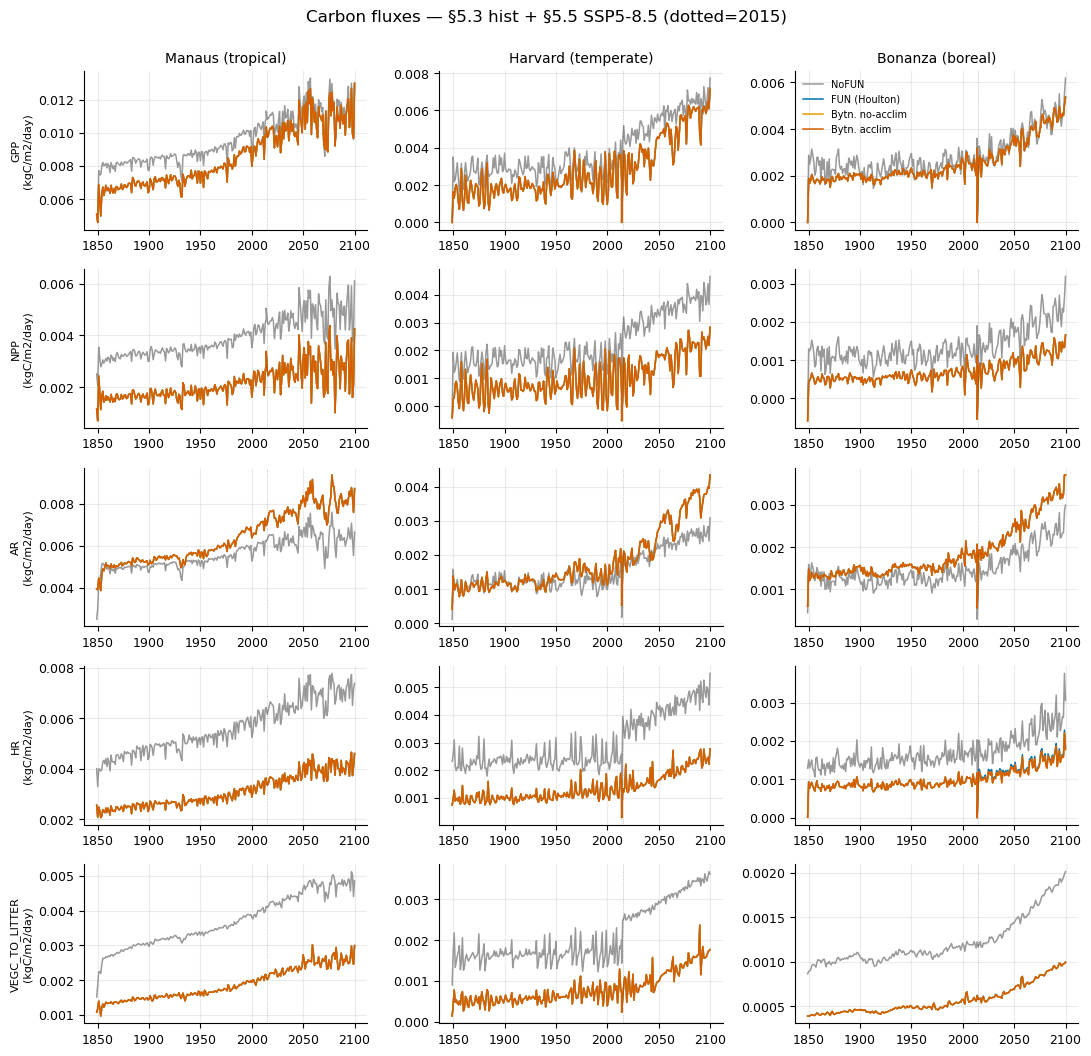

In [4]:
plot_group(['GPP','NPP','AR','HR','VEGC_TO_LITTER'],'Carbon fluxes — §5.3 hist + §5.5 SSP5-8.5 (dotted=2015)')

## Carbon pools  (kgC m⁻²)

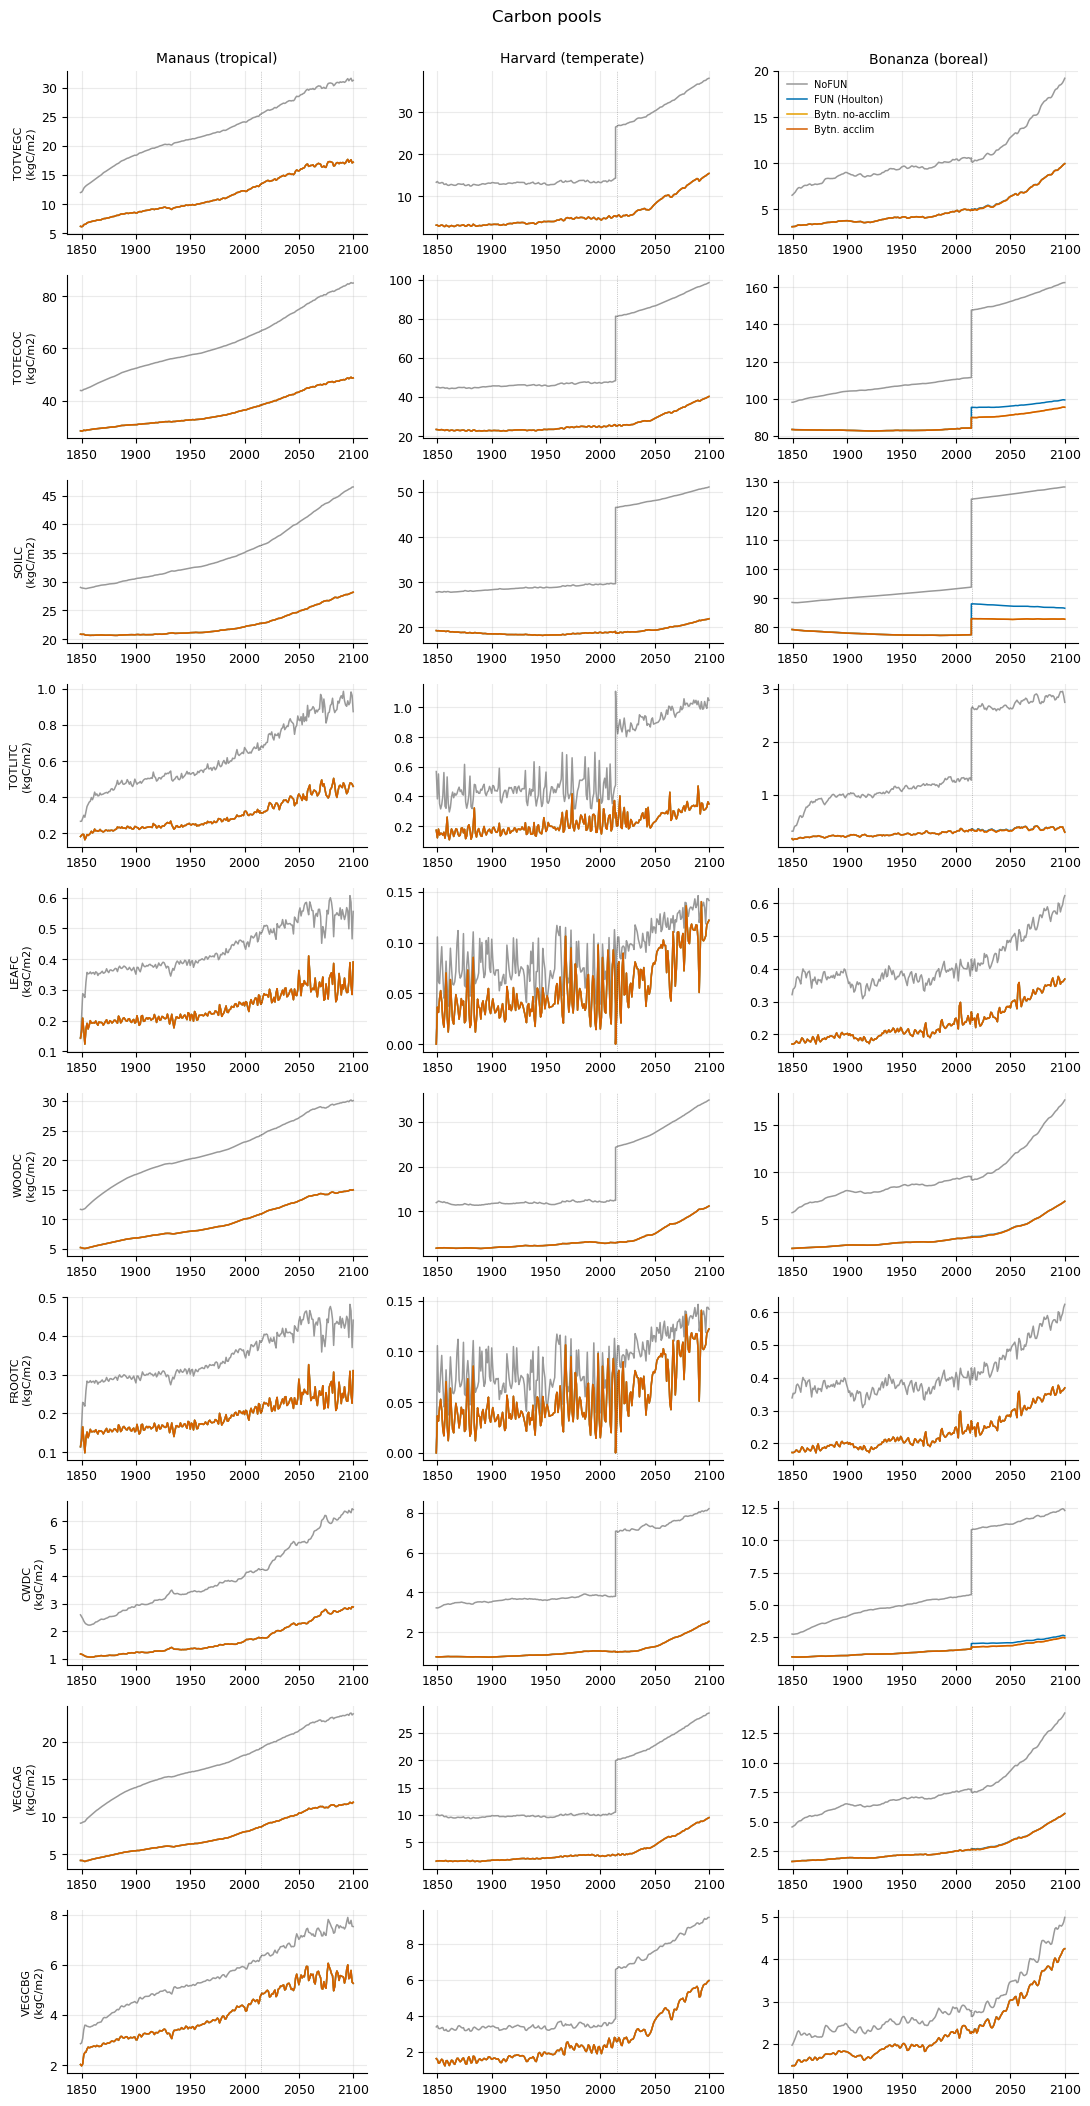

In [5]:
plot_group(['TOTVEGC','TOTECOC','SOILC','TOTLITC','LEAFC','WOODC','FROOTC','CWDC','VEGCAG','VEGCBG'],'Carbon pools')

## Nitrogen fixation  (kgN m⁻² day⁻¹)  — the MIP's focus

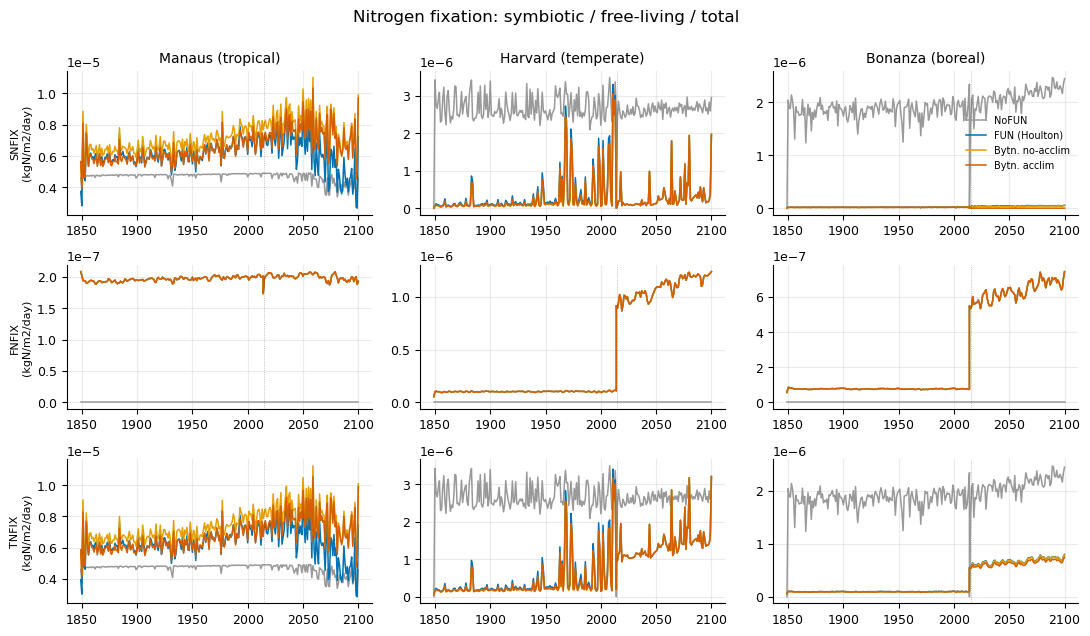

In [6]:
plot_group(['SNFIX','FNFIX','TNFIX'],'Nitrogen fixation: symbiotic / free-living / total')

### BNF temperature response (monthly, §5.5) — Houlton vs Bytnerowicz

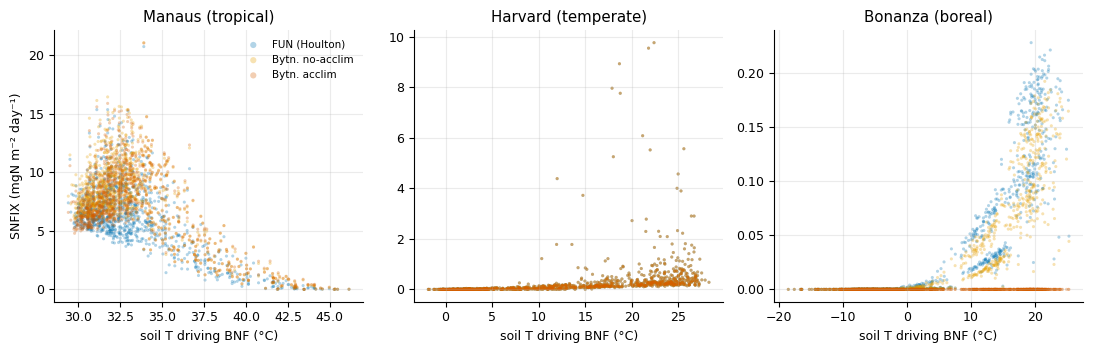

In [7]:
fig,axs=plt.subplots(1,3,figsize=(11,3.6))
for ax,(sid,sname) in zip(axs,SITES):
    for exp,elab in [('fun_transient_only','FUN (Houlton)'),('noacc_transient','Bytn. no-acclim'),('acc_transient','Bytn. acclim')]:
        ds=DATA.get((sid,exp,'55'))
        if ds is not None and 'TSOIBNF' in ds and 'SNFIX' in ds:
            ax.scatter(ds['TSOIBNF'].values-273.15, ds['SNFIX'].values*1e6, s=5,alpha=0.3,color=CE[exp],label=elab,edgecolors='none')
    ax.set_title(sname);ax.set_xlabel('soil T driving BNF (°C)')
    if sid=='BNF-Man': ax.legend(fontsize=7.5,frameon=False,markerscale=2)
axs[0].set_ylabel('SNFIX (mgN m⁻² day⁻¹)');fig.tight_layout();plt.show()

## Nitrogen fluxes  (kgN m⁻² day⁻¹)

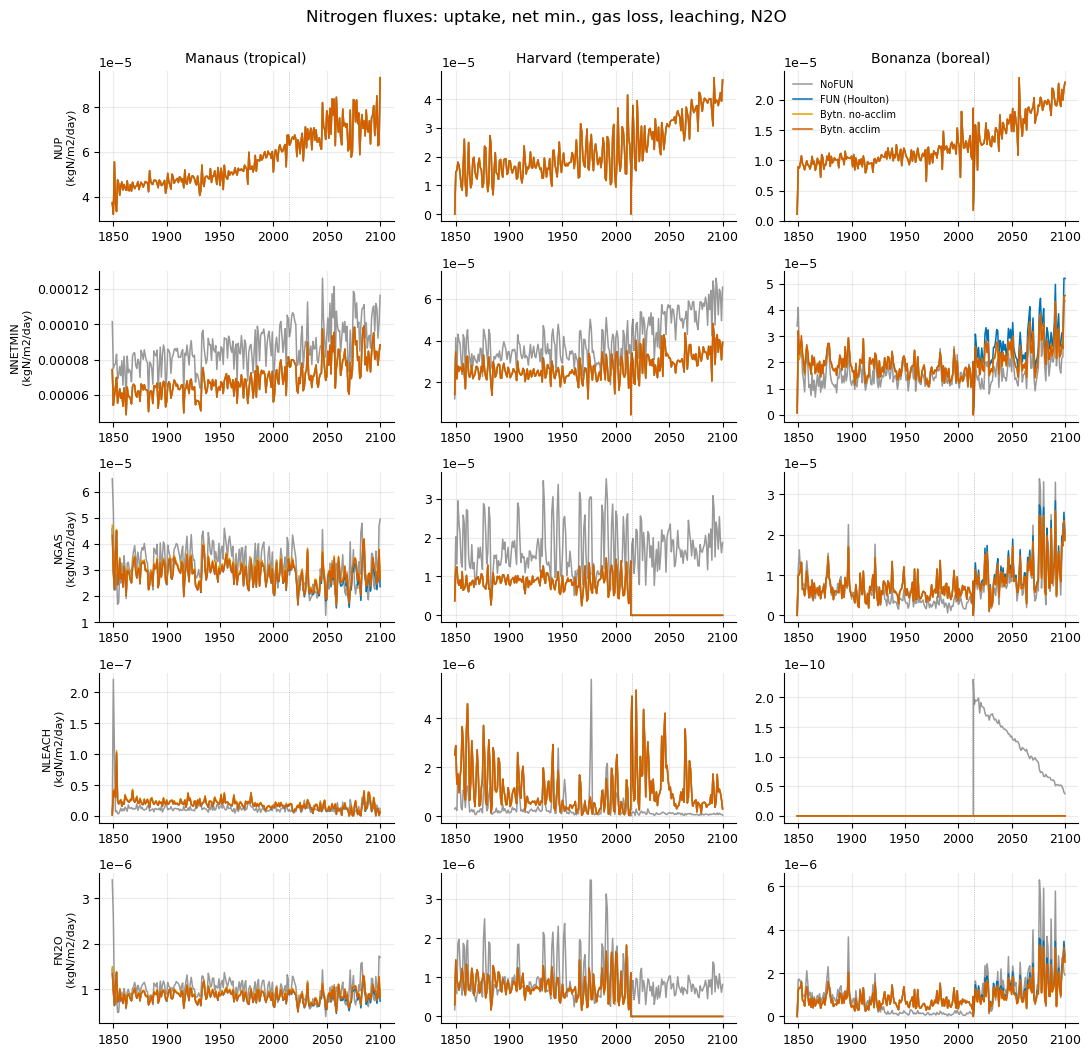

In [8]:
plot_group(['NUP','NNETMIN','NGAS','NLEACH','FN2O'],'Nitrogen fluxes: uptake, net min., gas loss, leaching, N2O')

## Nitrogen pools  (kgN m⁻²)

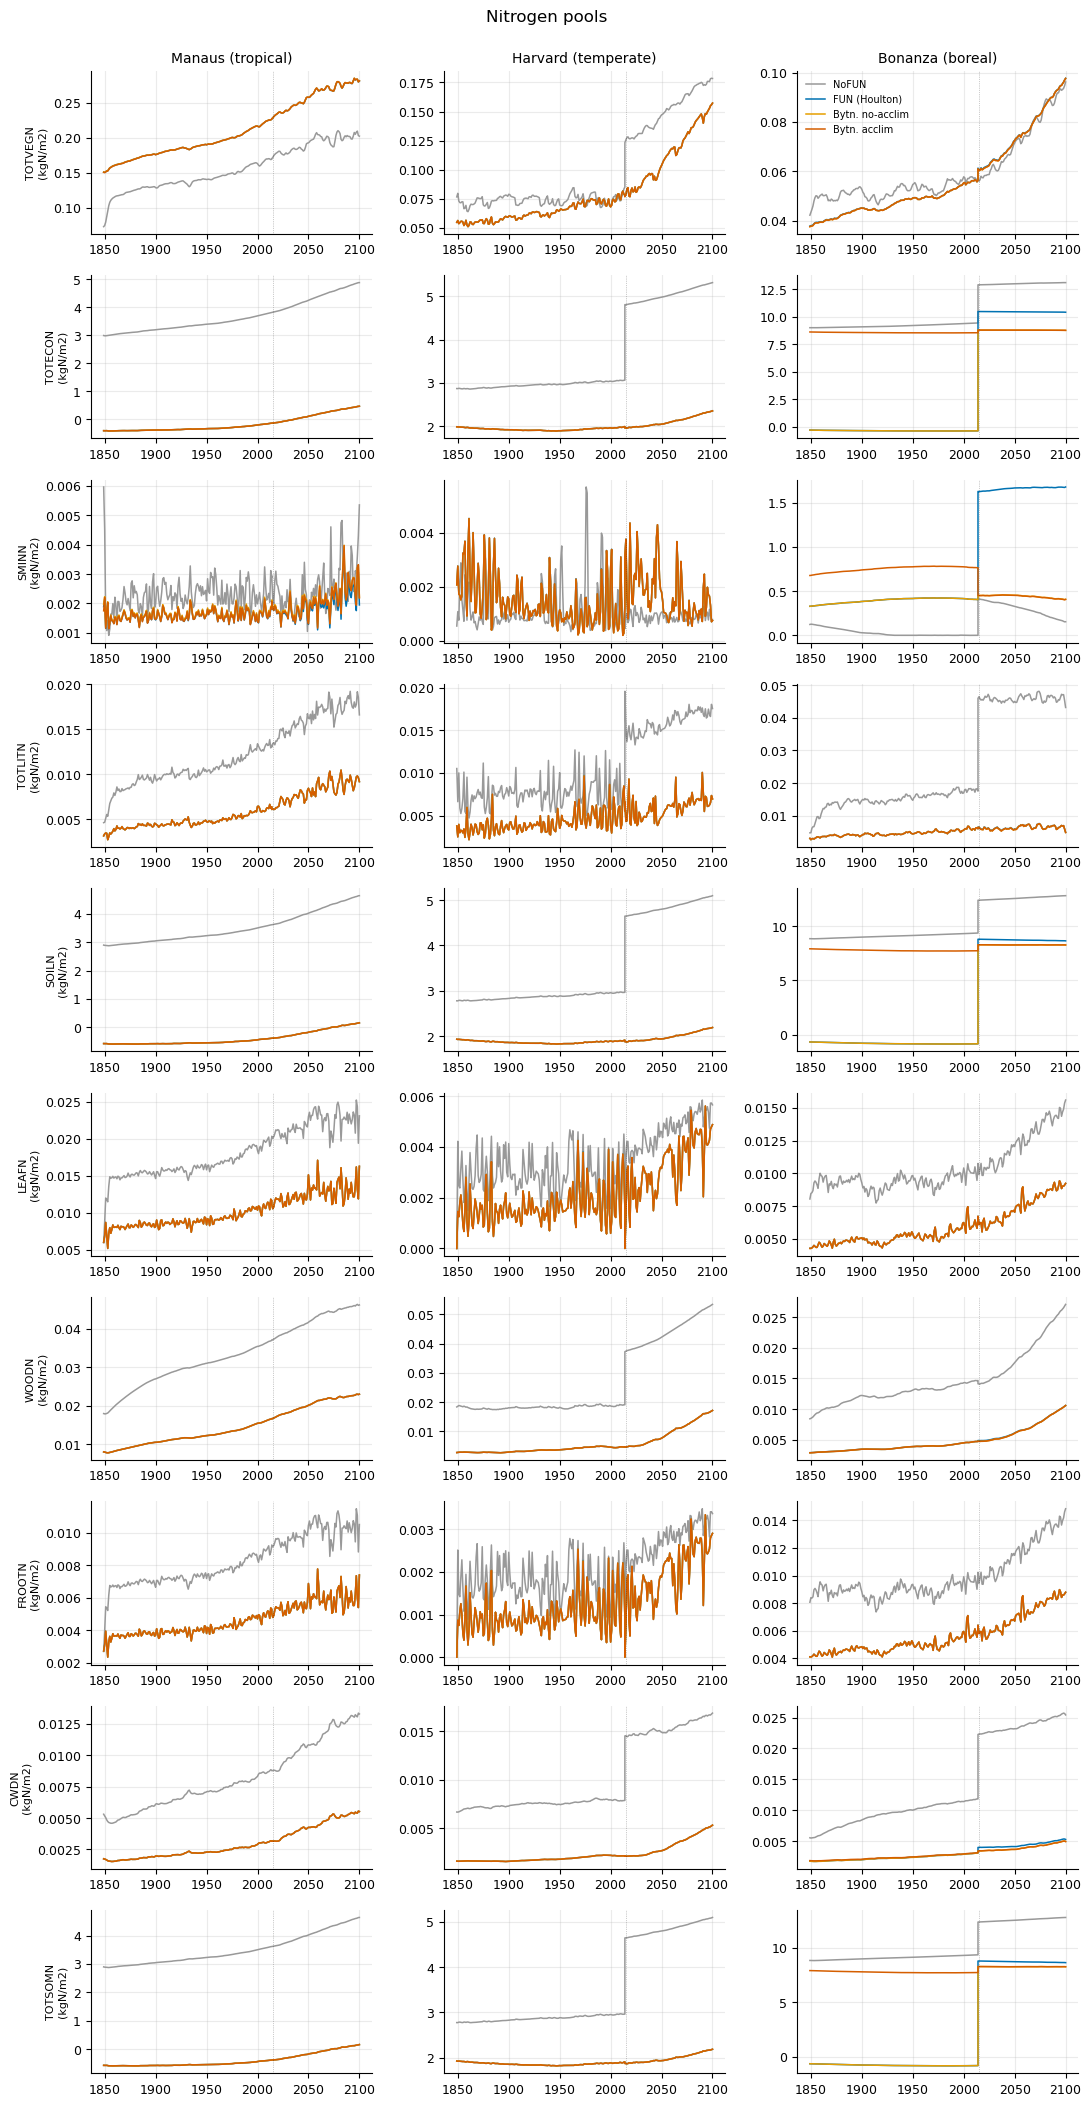

In [9]:
plot_group(['TOTVEGN','TOTECON','SMINN','TOTLITN','SOILN','LEAFN','WOODN','FROOTN','CWDN','TOTSOMN'],'Nitrogen pools')

## Phosphorus pools  (kgP m⁻²)  — ELM-FUN unique (FUNP)

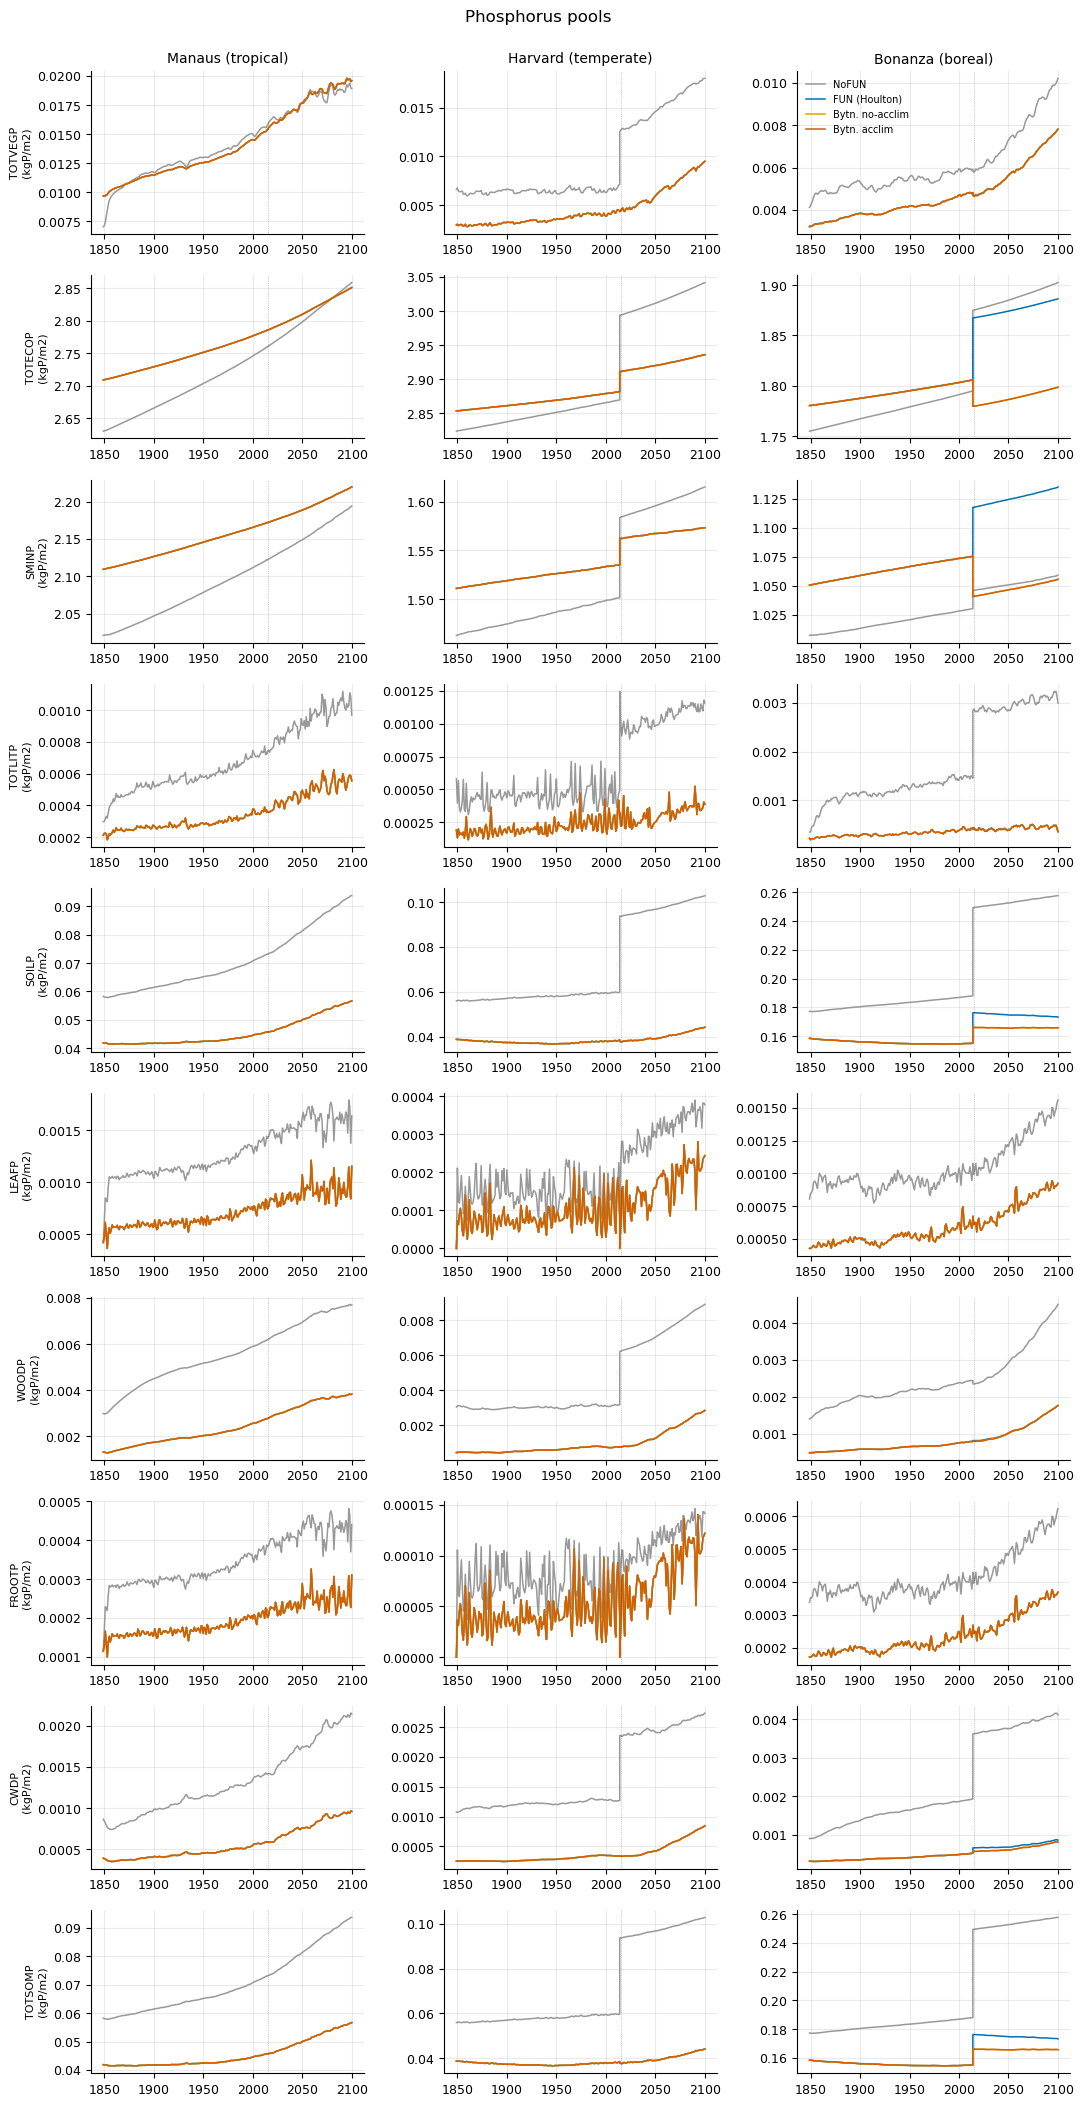

In [10]:
plot_group(['TOTVEGP','TOTECOP','SMINP','TOTLITP','SOILP','LEAFP','WOODP','FROOTP','CWDP','TOTSOMP'],'Phosphorus pools')

## Phosphorus fluxes  (kgP m⁻² day⁻¹)

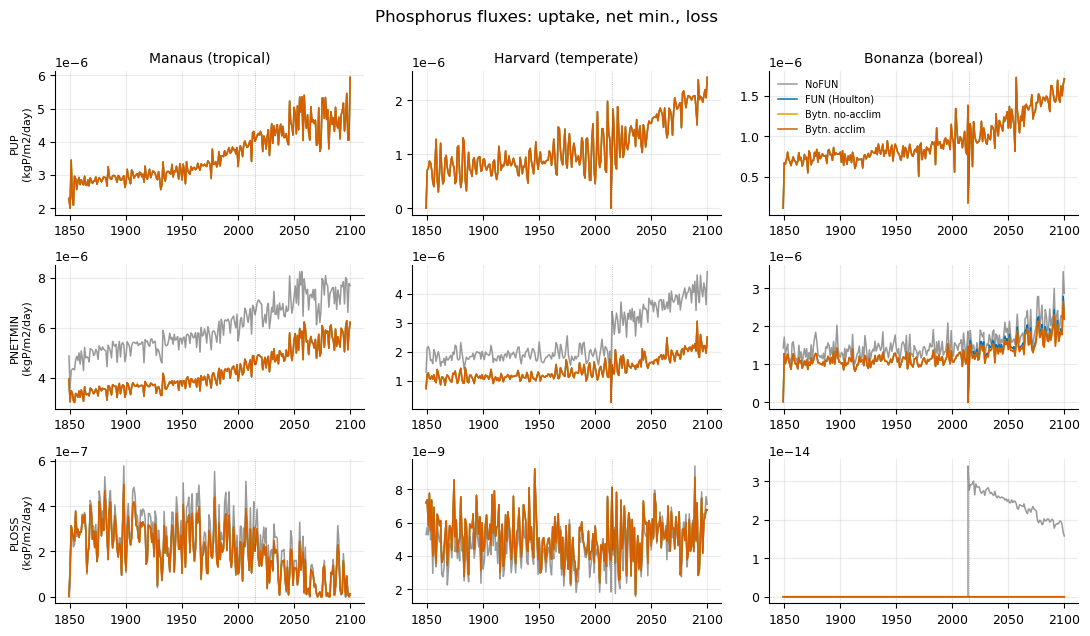

In [11]:
plot_group(['PUP','PNETMIN','PLOSS'],'Phosphorus fluxes: uptake, net min., loss')

## Physical & structural

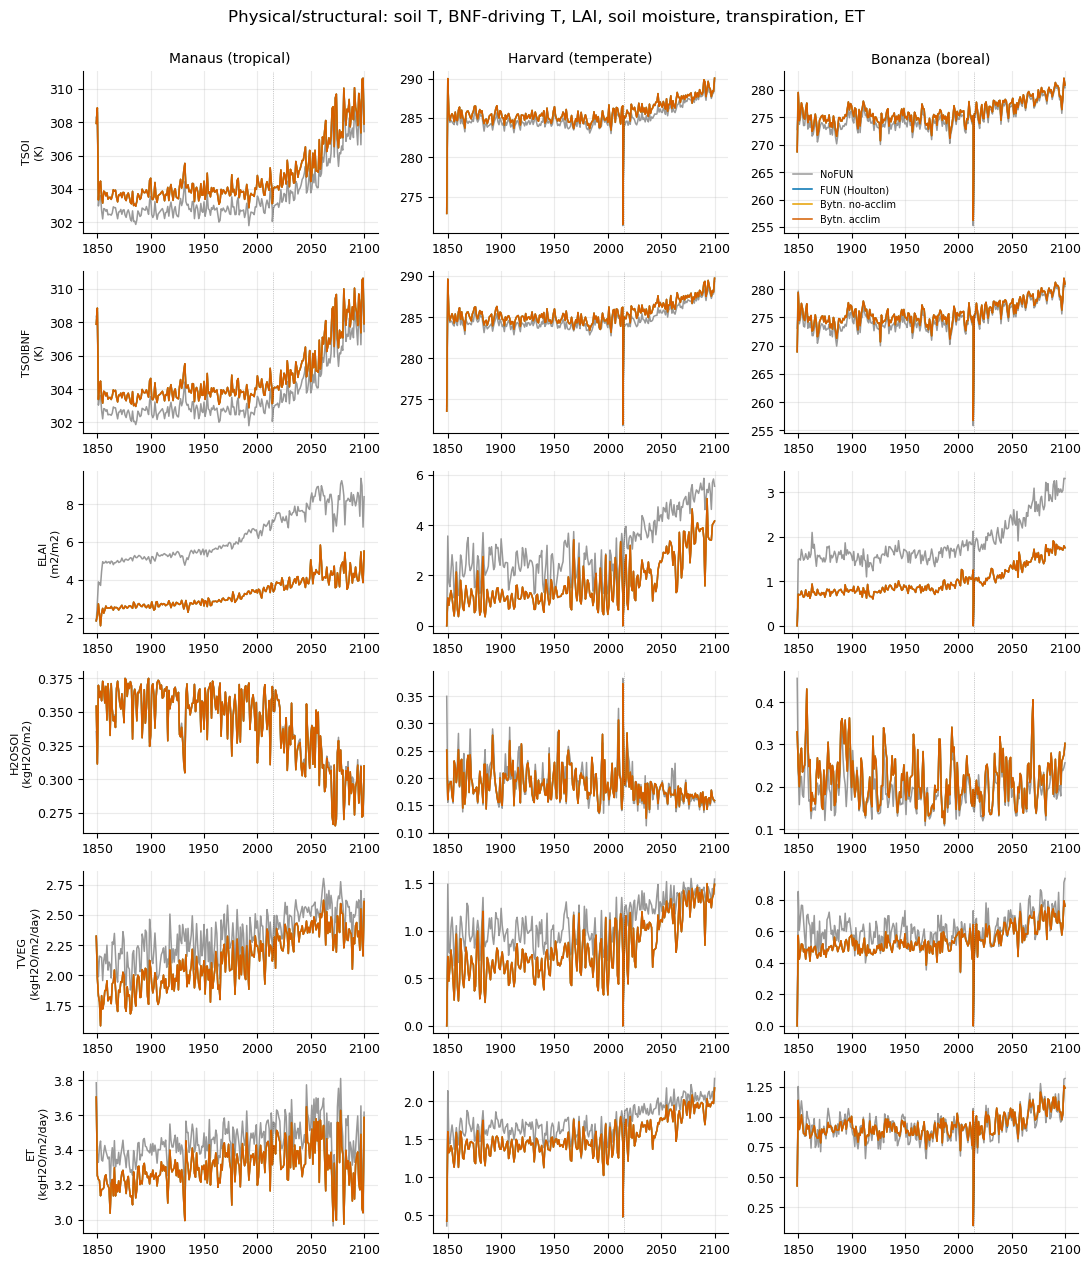

In [12]:
plot_group(['TSOI','TSOIBNF','ELAI','H2OSOI','TVEG','ET'],'Physical/structural: soil T, BNF-driving T, LAI, soil moisture, transpiration, ET')

## Notes & caveats
- Data source: `delivery_table2/` (identical to the tarball sent to coordinators).
- **Harvard** on PFT6 (broadleaf-deciduous *tropical*) vs protocol PFT7 (temperate): BNF
  temperature-response params identical, absolute C ~10–25% low. See `docs/corrections.md`.
- **H2OSOI** = ELM volumetric soil moisture (mm³/mm³), top layer shown.
- **SMINP** magnitude to be sanity-checked vs ELM P-pool definition.
- `TSOI`/`H2OSOI` shown as top soil layer; full profiles (all 15 layers) are in the files.